In [4]:
# CELDA 1: Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")
print("\n⚠️  Nota: La Regresión Logística requiere StandardScaler.")

✅ Librerías importadas correctamente
   pandas  2.2.2
   numpy   1.26.4
   seaborn 0.13.2

⚠️  Nota: La Regresión Logística requiere StandardScaler.


In [5]:
# CELDA 2: Carga de datos y variable objetivo
conn = psycopg2.connect(
    host='localhost', port=5432,
    database='divisas_db', user='etl_user', password='etl1234'
)

df = pd.read_sql("""
    SELECT moneda_destino, tasa_cambio, inversa,
           variacion_pct, volatilidad_7d, fecha_extraccion
    FROM tasas_cambio
    WHERE fecha_actualizacion_api = 'simulado'
    ORDER BY fecha_extraccion ASC
""", conn)
conn.close()

df['fecha_extraccion'] = pd.to_datetime(df['fecha_extraccion'])
df['dia'] = (df['fecha_extraccion'] - df['fecha_extraccion'].min()).dt.days
df['moneda_cod'] = pd.factorize(df['moneda_destino'])[0]
df['sube_tasa'] = (df['variacion_pct'] > 0).astype(int)

FEATURES = ['tasa_cambio', 'inversa', 'volatilidad_7d', 'dia', 'moneda_cod']
X = df[FEATURES]
y = df['sube_tasa']

print(f"✅ Datos cargados: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n🎯 Balance de la variable objetivo:")
print(f"   Tasa subió  (1): {y.sum():,}  ({y.mean()*100:.1f}%)")
print(f"   Tasa bajó   (0): {(y==0).sum():,}  ({(y==0).mean()*100:.1f}%)")
print(f"\n📋 Features: {FEATURES}")
df[['moneda_destino'] + FEATURES + ['sube_tasa']].head()

✅ Datos cargados: 1,000 filas × 9 columnas

🎯 Balance de la variable objetivo:
   Tasa subió  (1): 516  (51.6%)
   Tasa bajó   (0): 484  (48.4%)

📋 Features: ['tasa_cambio', 'inversa', 'volatilidad_7d', 'dia', 'moneda_cod']


/tmp/ipykernel_50670/1667470803.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


,moneda_destino,tasa_cambio,inversa,volatilidad_7d,dia,moneda_cod,sube_tasa
0,EUR,0.839169,1.191655,0.021031,0,0,0
1,COP,3766.745886,0.000265,13.655886,0,1,1
2,GBP,0.740860,1.349783,0.003540,0,2,0
3,JPY,155.793719,0.006419,2.106281,0,3,0
4,BRL,5.177812,0.193132,0.012812,0,4,1



  Split 80/20 — 80% Train / 20% Test
  Train: 800 muestras  |  Test: 200 muestras

  📊 MÉTRICAS (Split 80/20)
  ─────────────────────────────────────────────
  Accuracy  : 0.5400  — de cada 100, acierta 54.0
  Precision : 0.5000  — cuando predice 'subió', acierta 50.0%
  Recall    : 0.5652  — detecta el 56.5% de las subidas reales
  F1-Score  : 0.5306  — equilibrio entre Precision y Recall
  ROC-AUC   : 0.5441  — capacidad de separar las dos clases


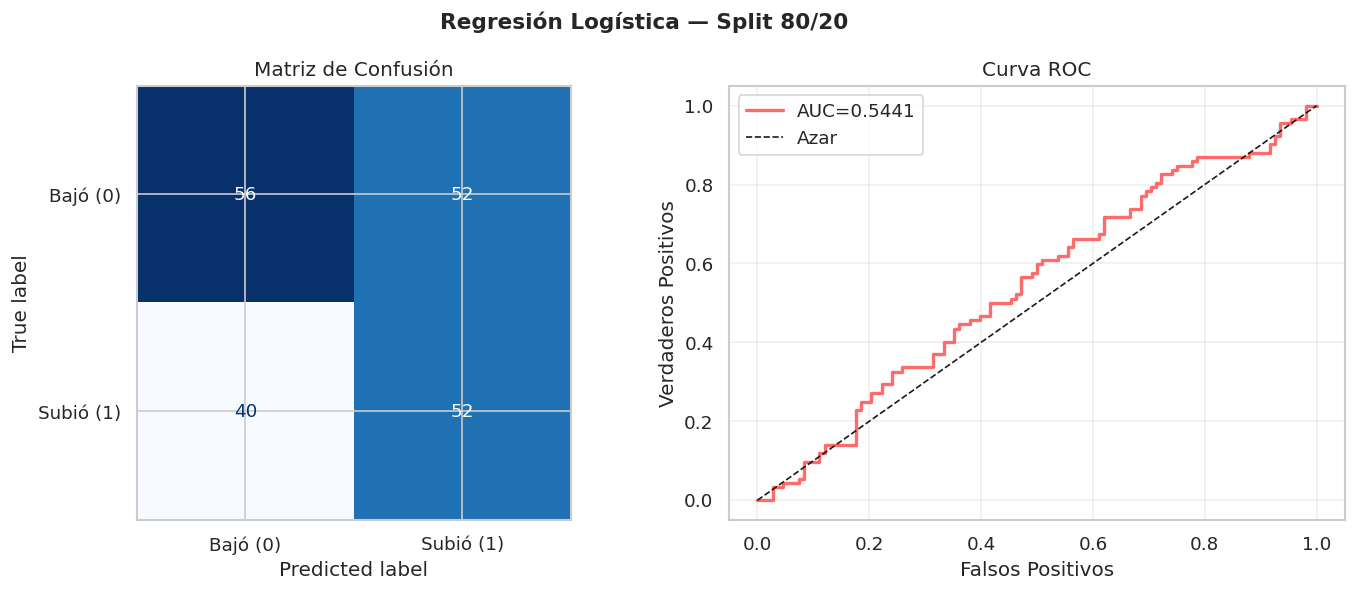


  Split 70/30 — 70% Train / 30% Test
  Train: 700 muestras  |  Test: 300 muestras

  📊 MÉTRICAS (Split 70/30)
  ─────────────────────────────────────────────
  Accuracy  : 0.5867  — de cada 100, acierta 58.7
  Precision : 0.5562  — cuando predice 'subió', acierta 55.6%
  Recall    : 0.6573  — detecta el 65.7% de las subidas reales
  F1-Score  : 0.6026  — equilibrio entre Precision y Recall
  ROC-AUC   : 0.5565  — capacidad de separar las dos clases


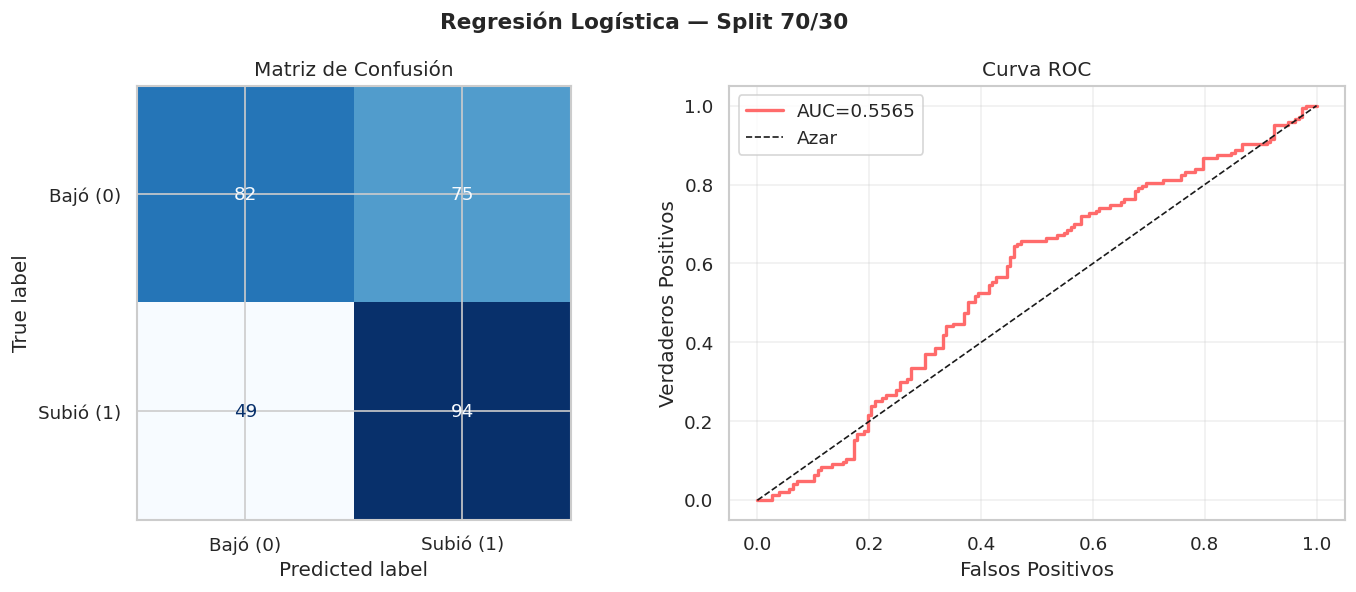


  Split 60/40 — 60% Train / 40% Test
  Train: 600 muestras  |  Test: 400 muestras

  📊 MÉTRICAS (Split 60/40)
  ─────────────────────────────────────────────
  Accuracy  : 0.5625  — de cada 100, acierta 56.2
  Precision : 0.5541  — cuando predice 'subió', acierta 55.4%
  Recall    : 0.6400  — detecta el 64.0% de las subidas reales
  F1-Score  : 0.5940  — equilibrio entre Precision y Recall
  ROC-AUC   : 0.5674  — capacidad de separar las dos clases


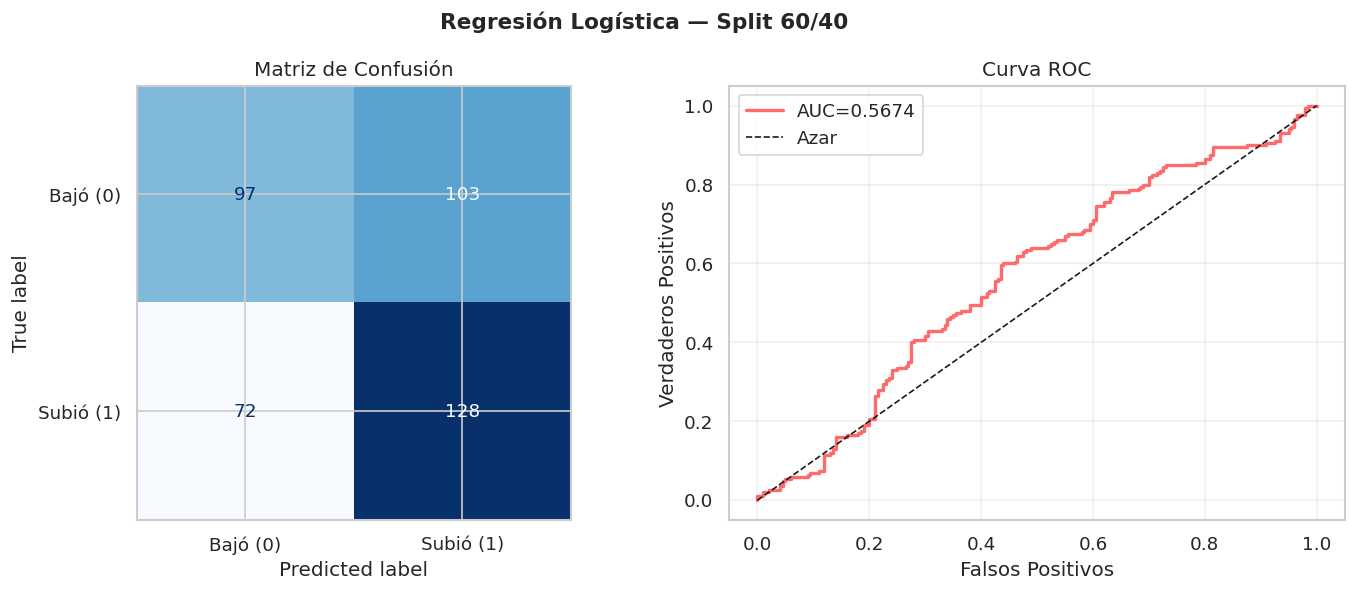

In [6]:
# CELDA 3: Función evaluar_split + 3 splits
scaler = StandardScaler()
resultados_globales = []

splits = [
    {'nombre': 'Split 80/20', 'test_size': 0.20},
    {'nombre': 'Split 70/30', 'test_size': 0.30},
    {'nombre': 'Split 60/40', 'test_size': 0.40},
]

def evaluar_split(X, y, test_size, split_label, resultados_globales):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # Escalado obligatorio para Regresión Logística
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    modelo = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

    print(f"\n{'='*58}")
    print(f"  {split_label} — {int((1-test_size)*100)}% Train / {int(test_size*100)}% Test")
    print(f"{'='*58}")
    print(f"  Train: {len(X_train):,} muestras  |  Test: {len(X_test):,} muestras")
    print(f"\n  📊 MÉTRICAS ({split_label})")
    print(f"  {'─'*45}")
    print(f"  Accuracy  : {acc:.4f}  — de cada 100, acierta {acc*100:.1f}")
    print(f"  Precision : {prec:.4f}  — cuando predice 'subió', acierta {prec*100:.1f}%")
    print(f"  Recall    : {rec:.4f}  — detecta el {rec*100:.1f}% de las subidas reales")
    print(f"  F1-Score  : {f1:.4f}  — equilibrio entre Precision y Recall")
    print(f"  ROC-AUC   : {auc:.4f}  — capacidad de separar las dos clases")

    resultados_globales.append({
        'Split': split_label, 'Train': len(X_train), 'Test': len(X_test),
        'Accuracy': round(acc,4), 'Precision': round(prec,4),
        'Recall': round(rec,4), 'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4),
        'modelo': modelo, 'X_test_sc': X_test_sc,
        'y_test': y_test, 'y_pred': y_pred, 'y_prob': y_prob
    })

    # Matriz de confusión + Curva ROC
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Regresión Logística — {split_label}', fontsize=13, fontweight='bold')

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Bajó (0)', 'Subió (1)']).plot(
        ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title('Matriz de Confusión')

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, color='#ff6b6b', linewidth=2, label=f'AUC={auc:.4f}')
    axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Azar')
    axes[1].set_xlabel('Falsos Positivos')
    axes[1].set_ylabel('Verdaderos Positivos')
    axes[1].set_title('Curva ROC')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'data/logistica_{split_label.replace(" ","_").replace("/","-")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return modelo, X_test_sc, y_test, y_pred, y_prob

# Ejecutar los 3 splits
r1 = evaluar_split(X, y, 0.20, 'Split 80/20', resultados_globales)
r2 = evaluar_split(X, y, 0.30, 'Split 70/30', resultados_globales)
r3 = evaluar_split(X, y, 0.40, 'Split 60/40', resultados_globales)

In [7]:
# CELDA 4: Tabla resumen de métricas
resumen = pd.DataFrame([{k: v for k, v in r.items() 
                         if k not in ['modelo','X_test_sc','y_test','y_pred','y_prob']} 
                        for r in resultados_globales]).set_index('Split')

print("=" * 65)
print(f"{'REGRESIÓN LOGÍSTICA — TABLA FINAL DE MÉTRICAS':^65}")
print("=" * 65)
display(resumen.style
    .background_gradient(cmap='Greens', 
                         subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .set_caption("Regresión Logística — Clasificación: ¿Subió la tasa?")
)

          REGRESIÓN LOGÍSTICA — TABLA FINAL DE MÉTRICAS          


,Train,Test,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,800,200,0.5400,0.5000,0.5652,0.5306,0.5441
Split 70/30,700,300,0.5867,0.5562,0.6573,0.6026,0.5565
Split 60/40,600,400,0.5625,0.5541,0.6400,0.5940,0.5674


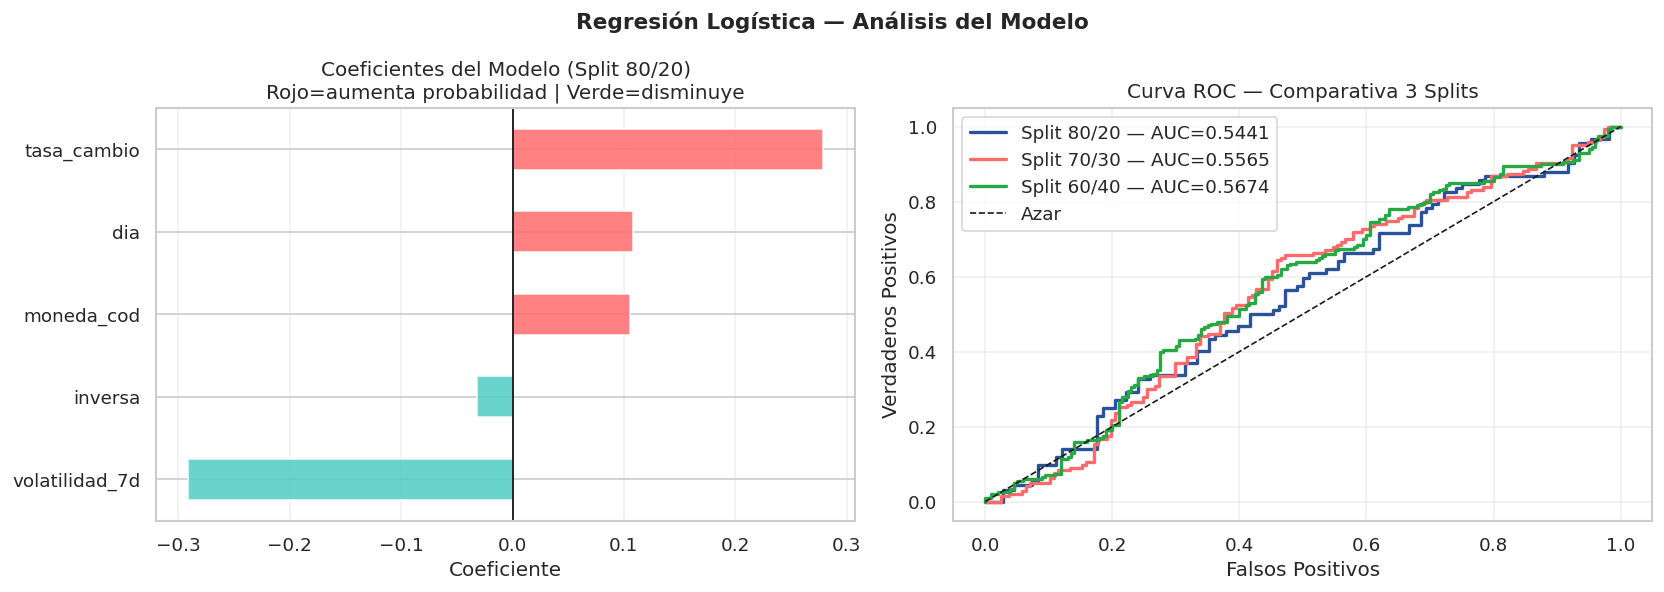

In [8]:
# CELDA 5: Coeficientes + Curva ROC comparativa
modelo_s1 = resultados_globales[0]['modelo']
coef = pd.Series(modelo_s1.coef_[0], index=FEATURES).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regresión Logística — Análisis del Modelo', fontsize=13, fontweight='bold')

# Gráfica de coeficientes
colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in coef]
coef.plot(kind='barh', ax=axes[0], color=colores, alpha=0.85)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Coeficientes del Modelo (Split 80/20)\nRojo=aumenta probabilidad | Verde=disminuye')
axes[0].set_xlabel('Coeficiente')
axes[0].grid(axis='x', alpha=0.3)

# Curva ROC comparativa de los 3 splits
colores_roc = ['#2a5298', '#ff6b6b', '#28a745']
for i, r in enumerate(resultados_globales):
    fpr, tpr, _ = roc_curve(r['y_test'], r['y_prob'])
    axes[1].plot(fpr, tpr, color=colores_roc[i], linewidth=2,
                 label=f"{r['Split']} — AUC={r['ROC-AUC']:.4f}")
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Azar')
axes[1].set_xlabel('Falsos Positivos')
axes[1].set_ylabel('Verdaderos Positivos')
axes[1].set_title('Curva ROC — Comparativa 3 Splits')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/logistica_coef_roc_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# CELDA 6: Conclusiones finales
print("""
╔══════════════════════════════════════════════════════════════╗
║         CONCLUSIONES — Regresión Logística                   ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Variable objetivo   : sube_tasa (1=subió, 0=bajó)          ║
║  Algoritmo           : LogisticRegression                    ║
║  Escalado            : StandardScaler (obligatorio)          ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║  Aspecto              Hallazgo                               ║
║  ─────────────────    ───────────────────────────────────    ║
║  Mejor split          60/40 — Accuracy 56.25%                ║
║  ROC-AUC promedio     ~0.55 — apenas supera el azar          ║
║  Variable negativa    volatilidad_7d (coef. más negativo)    ║
║  Variable positiva    tasa_cambio (coef. más positivo)       ║
║  vs Árbol CART        CART supera ampliamente (99% vs 56%)   ║
║  Conclusión           Los datos tienen relación no lineal;   ║
║                       la Reg. Logística no es suficiente     ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         CONCLUSIONES — Regresión Logística                   ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Variable objetivo   : sube_tasa (1=subió, 0=bajó)          ║
║  Algoritmo           : LogisticRegression                    ║
║  Escalado            : StandardScaler (obligatorio)          ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║  Aspecto              Hallazgo                               ║
║  ─────────────────    ───────────────────────────────────    ║
║  Mejor split          60/40 — Accuracy 56.25%                ║
║  ROC-AUC promedio     ~0.55 — apenas supera el azar          ║
║  Variable negativa    volatilidad_7d (coef. más negativo)    ║
║  Variable positiva    tasa_cambio (coef. más positivo)       ║
║  vs Árbol CART        C